In [ ]:
import pandas as pd

df = pd.read_csv("/content/paved_safe_acc_const-acc-at-40kmph_28-2-2023_15-48-43.csv")

print(df.shape)
print(df.columns.tolist())
print(df['event_class'].unique())
print(df['harsh_event'].unique())
print(df.head())

(1114, 14)
['sr_no', 'timestamp', 'road_type', 'harsh_event', 'acc_x', 'acc_y', 'acc_z', 'gyro_x', 'gyro_y', 'gyro_z', 'mag_x', 'mag_y', 'mag_z', 'event_class']
[0]
['cons-acc-40']
   sr_no                  timestamp road_type  harsh_event     acc_x  \
0      1  28-2-2023_15:49:11:229189     paved  cons-acc-40 -2.178610   
1      2  28-2-2023_15:49:11:585986     paved  cons-acc-40 -1.373871   
2      3  28-2-2023_15:49:11:592806     paved  cons-acc-40  0.139804   
3      4  28-2-2023_15:49:11:600804     paved  cons-acc-40  0.312248   
4      5  28-2-2023_15:49:11:632802     paved  cons-acc-40 -0.789478   

      acc_y     acc_z    gyro_x    gyro_y    gyro_z       mag_x      mag_y  \
0 -0.561066 -6.170253 -0.136220  0.104317  0.021117 -103.157516  97.044243   
1  3.041099 -0.450859 -0.036616  0.013768  0.016589 -103.157516  97.044243   
2 -1.193361  2.260345 -0.049932 -0.056275 -0.007912 -103.982765  85.627274   
3 -2.390889  2.039999  0.007327 -0.047752  0.018187 -103.982765  85.627274

In [ ]:
import pandas as pd
import os

folder = "/content/archive"  # change this to your folder path

all_events = []

for file in os.listdir(folder):
    if file.endswith(".csv"):
        df = pd.read_csv(os.path.join(folder, file))
        # Check if the required columns exist before trying to access them
        if 'harsh_event' in df.columns and 'event_class' in df.columns:
            all_events.append(df[['harsh_event', 'event_class']].drop_duplicates())
        else:
            print(f"Skipping file '{file}' as it does not contain 'harsh_event' or 'event_class' columns.")

# Only proceed if there are any events collected
if all_events:
    event_map = pd.concat(all_events).drop_duplicates().sort_values('event_class')
    print(event_map.to_string())
else:
    print("No files with 'harsh_event' and 'event_class' columns were found in the specified folder.")

Skipping file 'traffic.csv' as it does not contain 'harsh_event' or 'event_class' columns.
               harsh_event  event_class
0            uniform-accel            0
0             sudden-brake            0
0        sudden-right-turn            0
0       cons-20-linechange            0
0      sudden-acceleration            0
0     sudden-left-line-chg            0
0         Safe-no-movement            0
0         sudden-line-left            0
0    sudden-right-line-chg            0
0              cons-acc-20            0
0        sudden-line-right            0
0              cons-acc-40            0
0         sudden-left-turn            0
0               sudden-acc            0
581           sudden-brake            1
135     cons-20-linechange            1
81    sudden-left-line-chg            1
95   sudden-right-line-chg            1
757    sudden-acceleration            1
460       sudden-line-left            1
234      sudden-right-turn            1
299      sudden-line-right   

In [ ]:
all_dfs = []

for file in os.listdir(folder):
    if file.endswith(".csv"):
        df = pd.read_csv(os.path.join(folder, file))
        if 'event_class' in df.columns:
            all_dfs.append(df)

combined = pd.concat(all_dfs, ignore_index=True)

print("Total rows:", len(combined))
print("\nClass distribution:")
print(combined['event_class'].value_counts())
print("\nIn percentage:")
print(combined['event_class'].value_counts(normalize=True) * 100)

Total rows: 32987

Class distribution:
event_class
0    23487
1     9500
Name: count, dtype: int64

In percentage:
event_class
0    71.200776
1    28.799224
Name: proportion, dtype: float64


In [ ]:
combined.to_csv("combined_dataset.csv", index=False)
print("Saved. Shape:", combined.shape)
print(combined[['acc_x','acc_y','acc_z','gyro_x','gyro_y','gyro_z','event_class']].head())

Saved. Shape: (32987, 14)
      acc_x     acc_y     acc_z    gyro_x    gyro_y    gyro_z  event_class
0 -0.141002 -2.618333 -1.501572 -0.087107 -0.005499 -0.004725            0
1 -0.255964 -1.267521 -0.610611 -0.076188  0.002490 -0.003659            0
2 -0.313446 -0.223277  1.200050 -0.059943  0.003023  0.001667            0
3  0.088924 -2.551271 -2.804482 -0.101222 -0.005499 -0.001795            0
4 -0.725395 -0.625646 -0.054956 -0.073791  0.004621  0.004597            0


In [ ]:
sample = pd.read_csv("combined_dataset.csv")
sample['timestamp'] = pd.to_datetime(
    sample['timestamp'].str.replace('_', ' '),
    format='%d-%m-%Y %H:%M:%S:%f'
)
sample = sample.head(100)

time_diff = sample['timestamp'].diff().dt.total_seconds()
print("Avg time between rows (seconds):", time_diff.mean().round(4))
print("Approx rows per second:", round(1 / time_diff.mean()))

Avg time between rows (seconds): 0.0519
Approx rows per second: 19


In [ ]:
import numpy as np

def create_windows(df, window_size=50, step_size=25):
    X = []  # features
    y = []  # labels

    for start in range(0, len(df) - window_size, step_size):
        end = start + window_size
        window = df.iloc[start:end]

        # label = most common class in this window
        label = window['event_class'].mode()[0]

        # features = raw sensor values flattened
        features = window[['acc_x','acc_y','acc_z',
                           'gyro_x','gyro_y','gyro_z']].values.flatten()

        X.append(features)
        y.append(label)

    return np.array(X), np.array(y)

combined = pd.read_csv("combined_dataset.csv")
X, y = create_windows(combined)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Class distribution:", np.unique(y, return_counts=True))

X shape: (1318, 300)
y shape: (1318,)
Class distribution: (array([0, 1]), array([944, 374]))


In [ ]:
def extract_features(df, window_size=50, step_size=25):
    X = []
    y = []

    cols = ['acc_x','acc_y','acc_z','gyro_x','gyro_y','gyro_z']

    for start in range(0, len(df) - window_size, step_size):
        end = start + window_size
        window = df.iloc[start:end]

        features = []
        for col in cols:
            s = window[col]
            features.append(s.mean())
            features.append(s.std())
            features.append(s.max())
            features.append(s.min())
            features.append(s.max() - s.min())  # range

        # magnitude features
        acc_mag = np.sqrt(window['acc_x']**2 + window['acc_y']**2 + window['acc_z']**2)
        gyro_mag = np.sqrt(window['gyro_x']**2 + window['gyro_y']**2 + window['gyro_z']**2)

        features.append(acc_mag.mean())
        features.append(acc_mag.std())
        features.append(gyro_mag.mean())
        features.append(gyro_mag.std())

        label = window['event_class'].mode()[0]
        X.append(features)
        y.append(label)

    return np.array(X), np.array(y)

X, y = extract_features(combined)

print("X shape:", X.shape)
print("Features per window:", X.shape[1])

X shape: (1318, 34)
Features per window: 34


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# train
model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)
model.fit(X_train, y_train)

# evaluate
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Safe', 'Aggressive']))

              precision    recall  f1-score   support

        Safe       0.86      0.98      0.92       189
  Aggressive       0.92      0.61      0.74        75

    accuracy                           0.88       264
   macro avg       0.89      0.80      0.83       264
weighted avg       0.88      0.88      0.87       264



In [ ]:
model = RandomForestClassifier(
    n_estimators=100,
    class_weight={0: 1, 1: 3},  # punish missing aggressive 3x more
    random_state=42
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Safe', 'Aggressive']))

              precision    recall  f1-score   support

        Safe       0.86      0.98      0.92       189
  Aggressive       0.92      0.60      0.73        75

    accuracy                           0.87       264
   macro avg       0.89      0.79      0.82       264
weighted avg       0.88      0.87      0.86       264



In [ ]:
import os

def extract_features_from_window(window):
    cols = ['acc_x','acc_y','acc_z','gyro_x','gyro_y','gyro_z']
    features = []
    for col in cols:
        s = window[col]
        features.append(s.mean())
        features.append(s.std())
        features.append(s.max())
        features.append(s.min())
        features.append(s.max() - s.min())

    acc_mag = np.sqrt(window['acc_x']**2 + window['acc_y']**2 + window['acc_z']**2)
    gyro_mag = np.sqrt(window['gyro_x']**2 + window['gyro_y']**2 + window['gyro_z']**2)

    features.append(acc_mag.mean())
    features.append(acc_mag.std())
    features.append(gyro_mag.mean())
    features.append(gyro_mag.std())
    return features

folder = "/content/archive"
window_size = 50
step_size = 25

all_X = []
all_y = []

for file in os.listdir(folder):
    if not file.endswith(".csv"):
        continue
    df = pd.read_csv(os.path.join(folder, file))
    if 'event_class' not in df.columns:
        continue

    df = df.reset_index(drop=True)

    for start in range(0, len(df) - window_size, step_size):
        end = start + window_size
        window = df.iloc[start:end]
        features = extract_features_from_window(window)
        label = window['event_class'].mode()[0]
        all_X.append(features)
        all_y.append(label)

X = np.array(all_X)
y = np.array(all_y)

print("X shape:", X.shape)
print("Class distribution:", np.unique(y, return_counts=True))

X shape: (1234, 34)
Class distribution: (array([0, 1]), array([859, 375]))


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Safe', 'Aggressive']))

              precision    recall  f1-score   support

        Safe       0.84      0.98      0.91       172
  Aggressive       0.93      0.57      0.71        75

    accuracy                           0.86       247
   macro avg       0.89      0.78      0.81       247
weighted avg       0.87      0.86      0.85       247



In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(f"                 Predicted Safe  Predicted Aggressive")
print(f"Actual Safe           {cm[0][0]}              {cm[0][1]}")
print(f"Actual Aggressive      {cm[1][0]}              {cm[1][1]}")

Confusion Matrix:
                 Predicted Safe  Predicted Aggressive
Actual Safe           169              3
Actual Aggressive      32              43


In [ ]:
def extract_features_from_window(window):
    cols = ['acc_x','acc_y','acc_z','gyro_x','gyro_y','gyro_z']
    features = []
    for col in cols:
        s = window[col]
        features.append(s.mean())
        features.append(s.std())
        features.append(s.max())
        features.append(s.min())
        features.append(s.max() - s.min())
        features.append(s.diff().abs().mean())  # ← jerk (rate of change)

    acc_mag = np.sqrt(window['acc_x']**2 + window['acc_y']**2 + window['acc_z']**2)
    gyro_mag = np.sqrt(window['gyro_x']**2 + window['gyro_y']**2 + window['gyro_z']**2)

    features.append(acc_mag.mean())
    features.append(acc_mag.std())
    features.append(acc_mag.max())        # ← peak force
    features.append(gyro_mag.mean())
    features.append(gyro_mag.std())
    features.append(gyro_mag.max())       # ← peak rotation

    return features

In [ ]:
# Step 1 - Re-extract features with jerk
all_X = []
all_y = []

for file in os.listdir(folder):
    if not file.endswith(".csv"):
        continue
    df = pd.read_csv(os.path.join(folder, file))
    if 'event_class' not in df.columns:
        continue

    df = df.reset_index(drop=True)

    for start in range(0, len(df) - window_size, step_size):
        end = start + window_size
        window = df.iloc[start:end]
        features = extract_features_from_window(window)
        label = window['event_class'].mode()[0]
        all_X.append(features)
        all_y.append(label)

X = np.array(all_X)
y = np.array(all_y)

# Step 2 - Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 3 - Train
model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)
model.fit(X_train, y_train)

# Step 4 - Evaluate
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Safe', 'Aggressive']))

# Step 5 - Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(f"                 Predicted Safe  Predicted Aggressive")
print(f"Actual Safe           {cm[0][0]}              {cm[0][1]}")
print(f"Actual Aggressive      {cm[1][0]}              {cm[1][1]}")

              precision    recall  f1-score   support

        Safe       0.84      0.98      0.91       172
  Aggressive       0.93      0.57      0.71        75

    accuracy                           0.86       247
   macro avg       0.89      0.78      0.81       247
weighted avg       0.87      0.86      0.85       247

Confusion Matrix:
                 Predicted Safe  Predicted Aggressive
Actual Safe           169              3
Actual Aggressive      32              43


In [ ]:
# Step 1 - Re-extract with smaller window
window_size = 25
step_size = 10

all_X = []
all_y = []

for file in os.listdir(folder):
    if not file.endswith(".csv"):
        continue
    df = pd.read_csv(os.path.join(folder, file))
    if 'event_class' not in df.columns:
        continue

    df = df.reset_index(drop=True)

    for start in range(0, len(df) - window_size, step_size):
        end = start + window_size
        window = df.iloc[start:end]
        features = extract_features_from_window(window)
        label = window['event_class'].mode()[0]
        all_X.append(features)
        all_y.append(label)

X = np.array(all_X)
y = np.array(all_y)

print("X shape:", X.shape)
print("Class distribution:", np.unique(y, return_counts=True))

# Step 2 - Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Step 3 - Train
model = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)
model.fit(X_train, y_train)

# Step 4 - Lower threshold + evaluate
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= 0.35).astype(int)

print(classification_report(y_test, y_pred, target_names=['Safe', 'Aggressive']))

# Step 5 - Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(f"                 Predicted Safe  Predicted Aggressive")
print(f"Actual Safe           {cm[0][0]}              {cm[0][1]}")
print(f"Actual Aggressive      {cm[1][0]}              {cm[1][1]}")

X shape: (3188, 42)
Class distribution: (array([0, 1]), array([2240,  948]))
              precision    recall  f1-score   support

        Safe       0.91      0.91      0.91       448
  Aggressive       0.79      0.79      0.79       190

    accuracy                           0.88       638
   macro avg       0.85      0.85      0.85       638
weighted avg       0.88      0.88      0.88       638

Confusion Matrix:
                 Predicted Safe  Predicted Aggressive
Actual Safe           409              39
Actual Aggressive      39              151


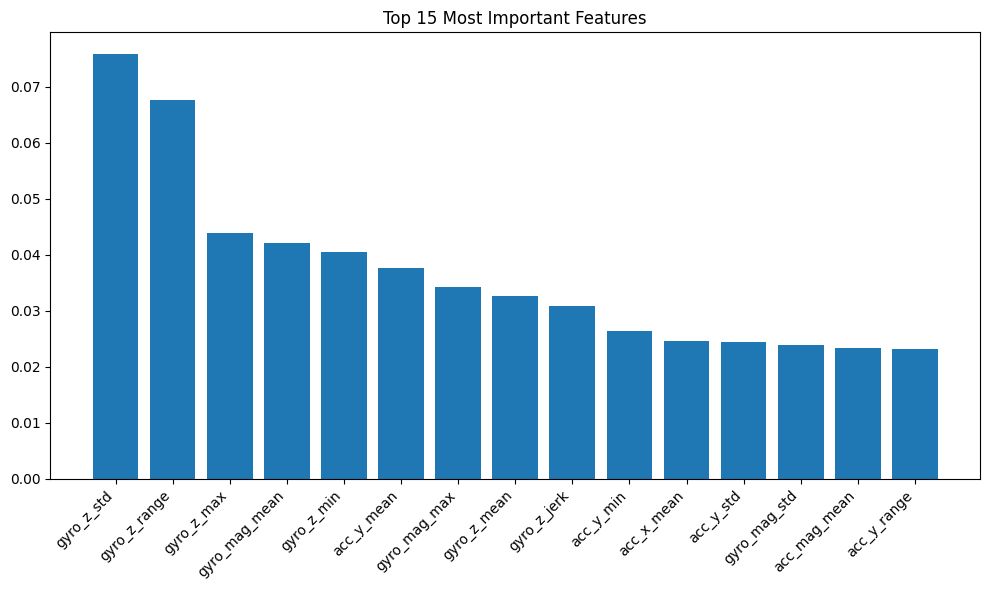

In [ ]:
import matplotlib.pyplot as plt

feature_names = []
for col in ['acc_x','acc_y','acc_z','gyro_x','gyro_y','gyro_z']:
    for stat in ['mean','std','max','min','range','jerk']:
        feature_names.append(f"{col}_{stat}")

feature_names += ['acc_mag_mean','acc_mag_std','acc_mag_max',
                  'gyro_mag_mean','gyro_mag_std','gyro_mag_max']

importances = model.feature_importances_
indices = np.argsort(importances)[::-1][:15]

plt.figure(figsize=(10,6))
plt.bar(range(15), importances[indices])
plt.xticks(range(15), [feature_names[i] for i in indices], rotation=45, ha='right')
plt.title("Top 15 Most Important Features")
plt.tight_layout()
plt.show()